# Phase 1: 数据集整理 (DataSet exposing)

## 概述 Overview

本Notebook文件基于Phase1脚本修改而来，目标为按照一定比例，融合不同专利的数据集，形成测试集和验证集


另外，这里新增了ChemBerta分子表征的内容，ChemBerta分子表征默认数值为384

**更新内容**

- 该脚本主要是获取论文需要的数据
- 在Phase1阶段就筛选对应的数据（is_monomer=True， 对应半衰期不为-1，SMILES不为空）
- **特殊情况需要注意：由于id失效导致Phase3中的筛选逻辑基本失效**
- **csv数据和npz特征数据只能是按顺序对应的内容**

**主要步骤：**
* 将五种专利的数据集整合，以相似度为边，建立无向图
* 按照独立联通分量作为聚类
* 按照独立分量中点的数目，大致按照7：3划分出数据集
* **重要更新：只获取monomer分子的内容**

**生成结果**
* csv文件（没有processed后缀，存放在data/similar/csv文件夹下方）
* npz文件（没有processed后缀，存放在data/similar/feature下方）

**输入**: `data/raw/*.csv` - 原始数据文件  
**输出**:  输出的每种文件包含Train/Test两种类型，所以csv和npz各为2种类，由于不需要分层所以直接弄两个
- `data/similar/csv/*.csv` - 添加分子特征后的CSV
- `data/similar/feature/*.npz` - RDKit特征矩阵   


---

## 1. 环境检查与导入 Environment Setup

In [13]:
# 环境检查
import sys
from pathlib import Path

# 添加项目根目录到路径
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

# 核心库导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# 项目模块导入
from feature_extraction import PeptideFeaturizer
from feature_extraction.utils import (
    get_csv_files, load_csv_safely, extract_molecular_features,
    convert_label_to_minutes, save_features_to_npz
)

# 设置显示选项
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("✓ 所有库已成功导入")
print(f"✓ 项目根目录: {project_root}")




✓ 所有库已成功导入
✓ 项目根目录: d:\RA\feature_extraction


## 2. 参数配置区 Configuration

**⚙️ 根据您的需求修改以下参数**

In [14]:
# ============== 参数配置区 ==============
# 用户可根据需要修改以下参数

CONFIG = {
    # 读入数据路径
    'raw_dir': project_root / 'data' / 'raw',
    # csv输出路径
    'processed_dir': project_root / 'data' / 'similar' / 'csv',
    'features_dir': project_root / 'data' / 'similar' / 'features',
    #'figures_dir': project_root / 'data' / 'general'/ 'figures' / 'phase1',

    # 备注信息：（用于挑选对应的数据和特征）
    'message':"Morgan(1024)_Avalon(512)",#Morgan(1024)_Avalon(512)_ChemBERTa(384)
    
    # 特征提取参数
    'morgan_bits': 1024, #1024,     # Morgan指纹位数（这里临时修改为0，关闭特征提取）
    'avalon_bits': 512,      # Avalon指纹位数512
    'chemberta_bits': 0,   # 根据目前所知，这个只有0和384，剩下改了都没用
    # （放在外面配置了）'use_avalon': True ,      # 是否使用Avalon指纹（需RDKit支持） 

    # 可视化参数
    'dpi': 300,              # 图像分辨率
    'format': 'png',         # 图像格式 (png/pdf/svg)
    'display_plots': True,   # 是否在notebook中显示关键图表
    'max_display_plots': 3,  # 最多显示几个图表
    'split_random':90
}

# 追加配置
CONFIG['use_avalon'] = True if CONFIG['avalon_bits'] > 0 else False  # 是否使用Avalon指纹（需RDKit支持）
CONFIG['use_chemberta'] = True if CONFIG['chemberta_bits'] > 0 else False  # 是否使用Avalon指纹（需RDKit支持）

# 创建输出目录
CONFIG['processed_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['features_dir'].mkdir(parents=True, exist_ok=True)
# CONFIG['figures_dir'].mkdir(parents=True, exist_ok=True)

print("配置参数:")
for key, value in CONFIG.items():
    if isinstance(value, Path):
        print(f"  {key}: {value.relative_to(project_root) if value.is_relative_to(project_root) else value}")
    else:
        print(f"  {key}: {value}")

配置参数:
  raw_dir: data\raw
  processed_dir: data\similar\csv
  features_dir: data\similar\features
  message: Morgan(1024)_Avalon(512)
  morgan_bits: 1024
  avalon_bits: 512
  chemberta_bits: 0
  dpi: 300
  format: png
  display_plots: True
  max_display_plots: 3
  split_random: 90
  use_avalon: True
  use_chemberta: False


## 3. 步骤 1: 添加分子特征 Add Molecular Features

为每个SMILES分子添加结构特征并转换标签格式。

**新增列**:
- `is_dimer`: 是否为二聚体 (bool)
- `is_cyclic`: 是否含环状结构 (bool)
- `has_disulfide_bond`: 是否含二硫键 (bool)
- `SIF_minutes`: SIF半衰期（分钟）
- `SGF_minutes`: SGF半衰期（分钟）

sif_sgf_second.csv原本数据长度897
sif_sgf_second.csv清理空SMILE长度897


sif_sgf_second.csv清理空数字558
sif_sgf_second.csv清理非单体202
US20140294902A1.csv原本数据长度5
US20140294902A1.csv清理空SMILE长度5


US20140294902A1.csv清理空数字5
US20140294902A1.csv清理非单体5
US9624268.csv原本数据长度775
US9624268.csv清理空SMILE长度775


US9624268.csv清理空数字130
US9624268.csv清理非单体130
US9809623B2.csv原本数据长度80
US9809623B2.csv清理空SMILE长度76


US9809623B2.csv清理空数字76
US9809623B2.csv清理非单体28
WO2017011820A2.csv原本数据长度174
WO2017011820A2.csv清理空SMILE长度173


WO2017011820A2.csv清理空数字158
WO2017011820A2.csv清理非单体150
筛选之前的sif数据 515
筛选之后的sif数据 515

>>> Analyzing Chemical Space for SIF...


Running UMAP for SIF...

>>> Analyzing Chemical Space for SGF...


Running UMAP for SGF...


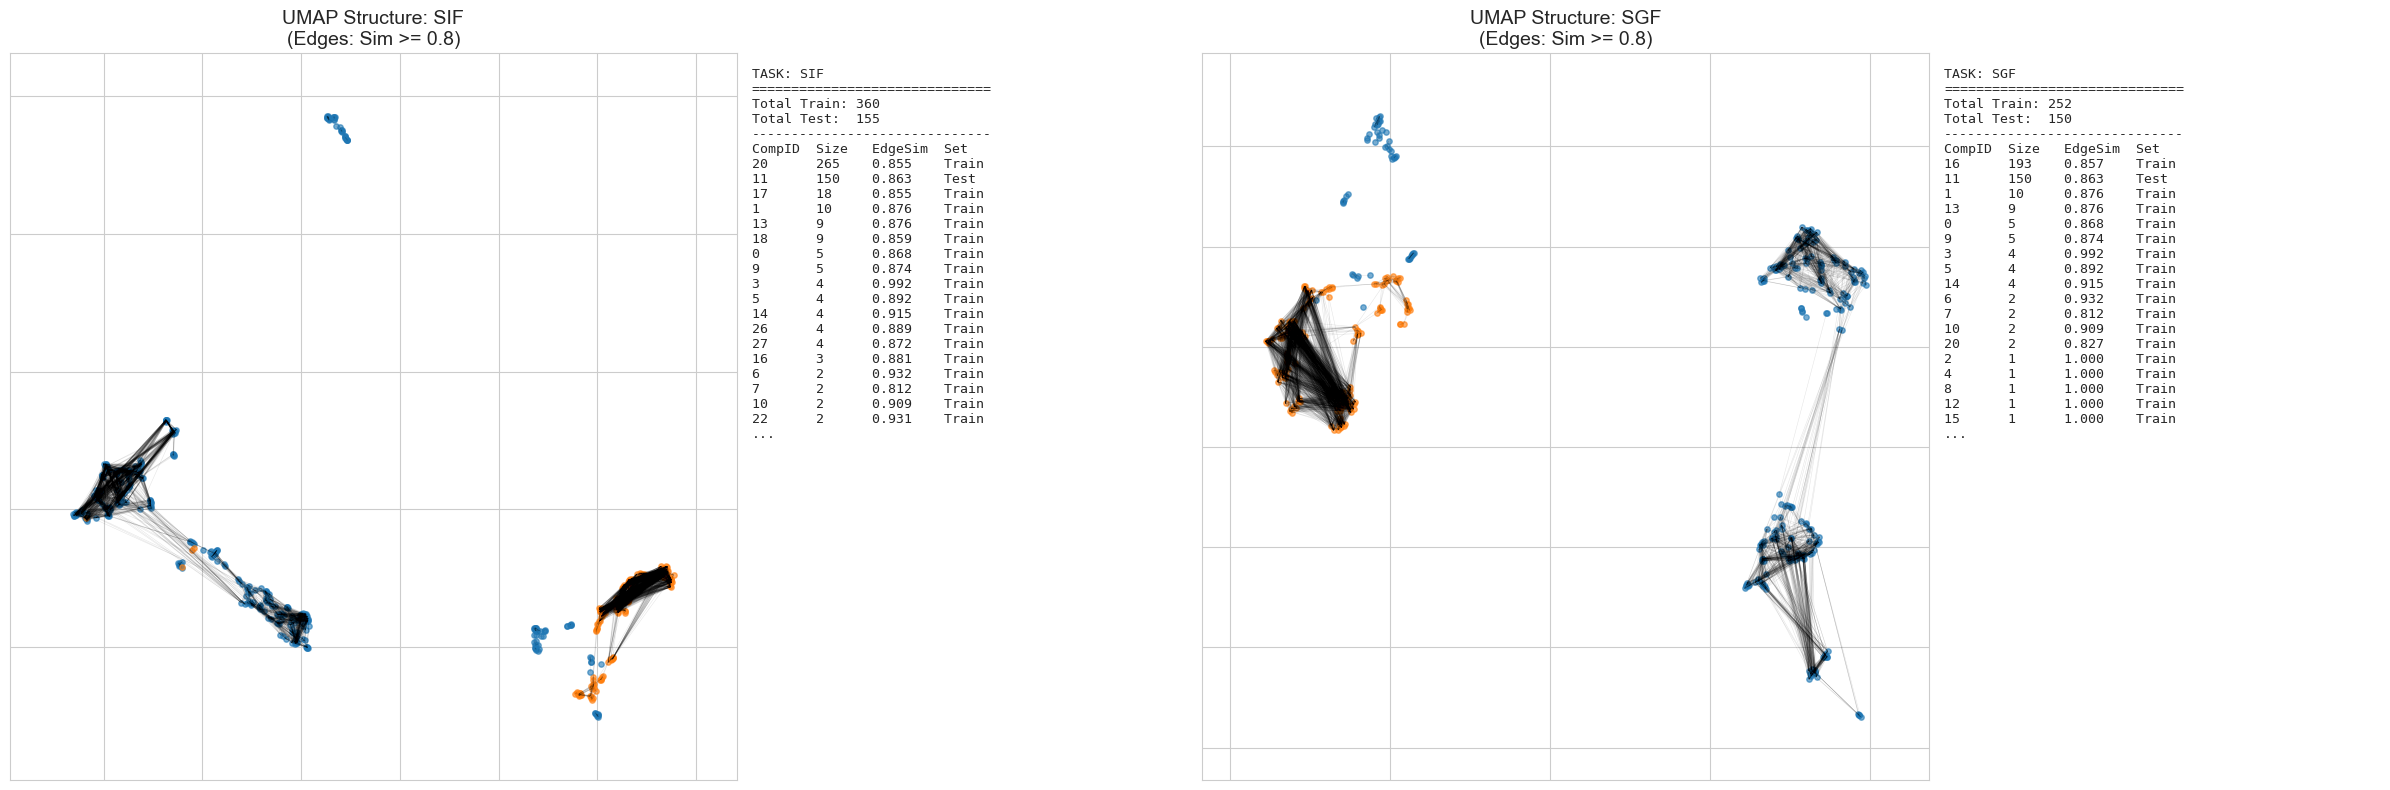

In [15]:
import pandas as pd
import numpy as np
import os
import warnings
from tqdm import tqdm
from pathlib import Path
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import networkx as nx
import umap

# 1. 屏蔽 RDKit 和 Python 警告
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.info')
warnings.filterwarnings("ignore")

def process_and_merge_datasets(file_paths, full_train_names, featurizer, train_ratio=0.7, message:str=""):
    """
    基于 Morgan 指纹进行连通分量划分，并增加 UMAP 拓扑可视化。
    Edge_Sim 仅计算满足阈值(>=0.8)的边的平均相似度。
    """
    # =========================
    # 第一阶段：数据处理 (逻辑不变)
    # =========================
    all_raw_data = []
    for path in file_paths:
        csv_path = CONFIG['raw_dir'] / path
        df = pd.read_csv(csv_path)
        print(f"{path}原本数据长度{len(df)}")
        df = df[df["SMILES"].notna()].copy()
        print(f"{path}清理空SMILE长度{len(df)}")
        # 提取分子特征
        feature_records = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"处理 {path}", leave=False):
            features = extract_molecular_features(row["SMILES"])
            feature_records.append(features)

        df = pd.concat([df, pd.DataFrame(feature_records)], axis=1)
        df["SIF_minutes"] = df["SIF_class"].apply(convert_label_to_minutes) if "SIF_class" in df.columns else -1
        df["SGF_minutes"] = df["SGF_class"].apply(convert_label_to_minutes) if "SGF_class" in df.columns else -1
        mask_both_missing = (df["SIF_minutes"] == -1) & (df["SGF_minutes"] == -1)
        df_processed = df[~mask_both_missing].copy()
        print(f"{path}清理空数字{len(df_processed)}")
        if "is_monomer" in df_processed.columns:
            df_processed = df_processed[df_processed["is_monomer"] == True].copy() #这里发生了问题
        else:
            print(f"--- 警告: {path} 中不存在 is_monomer 字段")
        print(f"{path}清理非单体{len(df_processed)}")
        df_processed["source_name"] = path
        all_raw_data.append(df_processed)

    master_df = pd.concat(all_raw_data, ignore_index=True)

    # =========================
    # 第二阶段：划分函数 (更新 Edge_Sim 统计)
    # =========================
    def graph_based_split(target_df, task_name):
        print(f"\n>>> Analyzing Chemical Space for {task_name}...")
        
        X_morgan = []
        valid_indices = []
        for idx, row in tqdm(target_df.iterrows(), total=len(target_df), desc=f"FP-{task_name}", leave=False):
            features, success = featurizer.featurize(row["SMILES"])
            if success and features is not None:
                X_morgan.append(features[-1024:]) # 截取最后1024位
                valid_indices.append(idx)
        
        fps = np.array(X_morgan, dtype=np.float32)
        
        # 相似度矩阵
        dot_matrix = fps @ fps.T
        sums = fps.sum(axis=1)
        union_matrix = sums[:, None] + sums[None, :] - dot_matrix
        sim_matrix = np.divide(dot_matrix, union_matrix, out=np.zeros_like(dot_matrix, dtype=float), where=union_matrix != 0)
        
        # 建立邻接矩阵 (Threshold >= 0.8)
        adj_matrix = (sim_matrix >= 0.8).astype(int)
        np.fill_diagonal(adj_matrix, 0) # 计算边均值时不计自环
        
        n_components, labels = connected_components(csgraph=csr_matrix(adj_matrix), directed=False)
        
        component_list = []
        for i in range(n_components):
            comp_indices = np.where(labels == i)[0]
            size = len(comp_indices)
            
            # 【核心修改】：仅计算在该分量内，相似度 >= 0.8 的“边”的平均相似度
            sub_sim = sim_matrix[np.ix_(comp_indices, comp_indices)]
            sub_adj = adj_matrix[np.ix_(comp_indices, comp_indices)]
            
            edges_values = sub_sim[sub_adj == 1]
            edge_sim_avg = edges_values.mean() if len(edges_values) > 0 else 1.0
            
            component_list.append({
                'label': i, 'size': size, 'edge_sim': edge_sim_avg, 
                'pos_in_fps': comp_indices, 'orig_indices': [valid_indices[p] for p in comp_indices]
            })

        # 7:3 贪心划分
        component_list.sort(key=lambda x: x['size'], reverse=True)
        target_train_size = len(valid_indices) * train_ratio
        current_train_count = 0
        
        for comp in component_list:
            if current_train_count + comp['size'] <= target_train_size:
                comp['assignment'] = 'Train'
                current_train_count += comp['size']
            else:
                comp['assignment'] = 'Test'
        
        print(f"Running UMAP for {task_name}...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='jaccard', random_state=42)
        embedding = reducer.fit_transform(fps)
        
        viz_data = {
            'embedding': embedding, 'adj_matrix': adj_matrix,
            'component_list': component_list, 'task_name': task_name
        }
        
        train_idx = [idx for c in component_list if c['assignment'] == 'Train' for idx in c['orig_indices']]
        test_idx = [idx for c in component_list if c['assignment'] == 'Test' for idx in c['orig_indices']]
        
        return target_df.loc[train_idx].copy(), target_df.loc[test_idx].copy(), viz_data

    # =========================
    # 第三阶段：执行逻辑
    # =========================
    def is_special(source_name):
        return any(spec in source_name for spec in full_train_names)

    # SIF 任务
    print("筛选之前的sif数据",len(master_df["SIF_minutes"]))
    sif_df = master_df[master_df["SIF_minutes"] != -1].copy()
    print("筛选之后的sif数据",len(sif_df))
    sif_df["label"] = (sif_df["SIF_minutes"] >= 270).astype(int)
    sif_must_train = sif_df[sif_df["source_name"].apply(is_special)]
    sif_candidate = sif_df[~sif_df["source_name"].apply(is_special)]
    train_sif, test_sif, viz_sif = graph_based_split(sif_candidate, "SIF")
    final_train_sif = pd.concat([sif_must_train, train_sif], ignore_index=True)

    # SGF 任务
    sgf_df = master_df[master_df["SGF_minutes"] != -1].copy()
    sgf_df["label"] = (sgf_df["SGF_minutes"] >= 250).astype(int)
    sgf_must_train = sgf_df[sgf_df["source_name"].apply(is_special)]
    sgf_candidate = sgf_df[~sgf_df["source_name"].apply(is_special)]
    train_sgf, test_sgf, viz_sgf = graph_based_split(sgf_candidate, "SGF")
    final_train_sgf = pd.concat([sgf_must_train, train_sgf], ignore_index=True)
    

    # --- 绘图与详细说明 ---
    def plot_all_results(v_sif, v_sgf, n_train_sif, n_test_sif, n_train_sgf, n_test_sgf):
        fig = plt.figure(figsize=(24, 8))
        gs = fig.add_gridspec(1, 4, width_ratios=[3, 1.8, 3, 1.8])
        
        results = [
            (v_sif, n_train_sif, n_test_sif),
            (v_sgf, n_train_sgf, n_test_sgf)
        ]
        
        for i, (viz, count_train, count_test) in enumerate(results):
            ax_plot = fig.add_subplot(gs[i*2])
            ax_text = fig.add_subplot(gs[i*2 + 1])
            ax_text.axis('off')
            
            emb = viz['embedding']
            comp_list = viz['component_list']
            
            # 画 UMAP
            for comp in comp_list:
                color = '#1f77b4' if comp['assignment'] == 'Train' else '#ff7f0e'
                ax_plot.scatter(emb[comp['pos_in_fps'], 0], emb[comp['pos_in_fps'], 1], 
                                s=15, c=color, alpha=0.6)
            
            # 画满足阈值的连边
            G = nx.from_numpy_array(viz['adj_matrix'])
            pos = {node: emb[node] for node in range(len(emb))}
            nx.draw_networkx_edges(G, pos, ax=ax_plot, edge_color='black', alpha=0.1, width=0.4)
            
            ax_plot.set_title(f"UMAP Structure: {viz['task_name']}\n(Edges: Sim >= 0.8)", fontsize=14)
            
            # 右侧英文说明文本
            info = f"TASK: {viz['task_name']}\n"
            info += f"{'='*30}\n"
            info += f"Total Train: {count_train}\n"
            info += f"Total Test:  {count_test}\n"
            info += f"{'-'*30}\n"
            info += f"{'CompID':<7} {'Size':<6} {'EdgeSim':<8} {'Set'}\n"
            
            for c in comp_list[:18]:
                info += f"{c['label']:<7} {c['size']:<6} {c['edge_sim']:<8.3f} {c['assignment']}\n"
            if len(comp_list) > 18: info += "...\n"
            
            ax_text.text(0, 0.98, info, family='monospace', fontsize=9.5, verticalalignment='top')

        plt.tight_layout()
        plt.show()

    # 显示结果
    plot_all_results(viz_sif, viz_sgf, len(final_train_sif), len(test_sif), len(final_train_sgf), len(test_sgf))

    # 保存文件
    final_train_sif.to_csv(CONFIG["processed_dir"]/f"Train_sif_{message}.csv", index=False)
    test_sif.to_csv(CONFIG["processed_dir"]/f"Test_sif_{message}.csv", index=False)
    final_train_sgf.to_csv(CONFIG["processed_dir"]/f"Train_sgf_{message}.csv", index=False)
    test_sgf.to_csv(CONFIG["processed_dir"]/f"Test_sgf_{message}.csv", index=False)

# --- 运行执行 ---
featurizer = PeptideFeaturizer(morgan_bits=1024, avalon_bits=0, chemberta_bits=0, use_avalon=False, use_chemberta=False)
csv_files_names = [f.name for f in CONFIG['raw_dir'].glob('*.csv')]
special_datasets = [] # 暂时不特殊对待任何数据集

process_and_merge_datasets(csv_files_names, special_datasets, featurizer=featurizer, message=CONFIG['message'])

## 4. 步骤 2: 提取RDKit特征 Extract RDKit Features

从处理后的CSV中提取分子特征向量，保存为NPZ格式。

**特征类型**:
- QED属性 (8维)
- 物理化学描述符 (11维)
- Gasteiger电荷统计 (5维)
- Morgan指纹 (1024维)
- Avalon指纹 (512维, 可选)

In [16]:
from pathlib import Path
def extract_rdkit_features(csv_path: Path, output_dir: Path, featurizer):
    """
    从CSV提取RDKit特征并保存为NPZ
    
    Args:
        csv_path: 输入CSV文件路径
        output_dir: 输出目录
        featurizer: PeptideFeaturizer实例
    
    Returns:
        dict: 统计信息
    """
    # 加载CSV
    df, _ = load_csv_safely(csv_path, required_columns=["id", "SMILES", "SIF_minutes", "SGF_minutes"])
    if df is None:
        return {"error": "Failed to load CSV"}
    
    X = []
    y_sif = []
    y_sgf = []
    ids = []
    valid_count = 0
    
    # 提取特征
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"提取特征 {csv_path.name}", leave=False):
        smiles = str(row["SMILES"])
        features, success = featurizer.featurize(smiles)
        
        if success and features is not None:
            X.append(features)
            y_sif.append(int(row["SIF_minutes"]) if not pd.isna(row["SIF_minutes"]) else -1)
            y_sgf.append(int(row["SGF_minutes"]) if not pd.isna(row["SGF_minutes"]) else -1)
            ids.append(str(row["id"]))
            valid_count += 1
    
    # 转换为NumPy数组
    X = np.array(X, dtype=np.float32)
    y_sif = np.array(y_sif, dtype=np.int32)
    y_sgf = np.array(y_sgf, dtype=np.int32)
    ids = np.array(ids, dtype=object)
    feature_names = featurizer.get_feature_names()
    
    # 保存NPZ
    output_path = output_dir / csv_path.name.replace('.csv', '.npz')
    np.savez_compressed(
        output_path,
        X=X,
        y_sif=y_sif,
        y_sgf=y_sgf,
        ids=ids,
        feature_names=feature_names,
    )
    
    return {
        "file": csv_path.name,
        "total_samples": len(df),
        "valid_samples": valid_count,
        "feature_dim": X.shape[1],
        "output_path": output_path,
    }

# 初始化特征提取器
featurizer = PeptideFeaturizer(
    morgan_bits=CONFIG['morgan_bits'],
    avalon_bits=CONFIG['avalon_bits'],
    chemberta_bits=CONFIG['chemberta_bits'],
    use_avalon=CONFIG['use_avalon'],
    use_chemberta=CONFIG['use_chemberta']
)

print(f"特征提取器配置:")
print(f"  Morgan指纹: {CONFIG['morgan_bits']} bits")
print(f"  Avalon指纹: {CONFIG['avalon_bits']} bits (启用: {CONFIG['use_avalon']})")
print(f"  ChemBerta指纹: {CONFIG['chemberta_bits']} bits (启用: {CONFIG['use_chemberta']})")
print(f"  预计总特征维度: {featurizer.n_features}\n")

# 执行：批量提取测试集特征
processed_csvs = list(CONFIG['processed_dir'].glob(f"Test_*_{CONFIG['message']}.csv"))
print(f"找到 {len(processed_csvs)} 个处理后的CSV文件\n")

feature_stats = []
for csv_file in processed_csvs:
    stats = extract_rdkit_features(csv_file, CONFIG['features_dir'], featurizer)
    if "error" not in stats:
        feature_stats.append(stats)
        print(f"✓ {stats['file']}: {stats['valid_samples']} samples, {stats['feature_dim']} features")

# 执行：批量提取训练集特征
processed_csvs = list(CONFIG['processed_dir'].glob(f"Train_*_{CONFIG['message']}.csv"))
print(f"找到 {len(processed_csvs)} 个处理后的CSV文件\n")

feature_stats = []
for csv_file in processed_csvs:
    stats = extract_rdkit_features(csv_file, CONFIG['features_dir'], featurizer)
    if "error" not in stats:
        feature_stats.append(stats)
        print(f"✓ {stats['file']}: {stats['valid_samples']} samples, {stats['feature_dim']} features")

# 汇总
feat_summary_df = pd.DataFrame(feature_stats)
print(f"\n{'='*60}")
print("特征提取总结:")
print(f"  总样本数: {feat_summary_df['valid_samples'].sum()}")
print(f"  特征维度: {feat_summary_df['feature_dim'].iloc[0]}")
print(f"{'='*60}\n")

display(feat_summary_df[['file', 'total_samples', 'valid_samples', 'feature_dim']])

特征提取器配置:
  Morgan指纹: 1024 bits
  Avalon指纹: 512 bits (启用: True)
  ChemBerta指纹: 0 bits (启用: False)
  预计总特征维度: 1560

找到 2 个处理后的CSV文件



✓ Test_sgf_Morgan(1024)_Avalon(512).csv: 150 samples, 1560 features


✓ Test_sif_Morgan(1024)_Avalon(512).csv: 155 samples, 1560 features
找到 2 个处理后的CSV文件



✓ Train_sgf_Morgan(1024)_Avalon(512).csv: 252 samples, 1560 features


✓ Train_sif_Morgan(1024)_Avalon(512).csv: 360 samples, 1560 features

特征提取总结:
  总样本数: 612
  特征维度: 1560



,file,total_samples,valid_samples,feature_dim
0,Train_sgf_Morgan(1024)_Avalon(512).csv,252,252,1560
1,Train_sif_Morgan(1024)_Avalon(512).csv,360,360,1560


## 5. 结果总结

Phase 1 数据转化已完成！

In [17]:
print("="*70)
print("Phase 1: 数据转化 - 执行完毕")
print("="*70)

print("\n📁 目前已有的文件:")
print(f"\n  1. 处理后的CSV ({len(list(CONFIG['processed_dir'].glob('*.csv')))} 个文件):")
for f in sorted(CONFIG['processed_dir'].glob('*_processed.csv')):
    print(f"     - {f.name}")

print(f"\n  2. 特征NPZ文件 ({len(list(CONFIG['features_dir'].glob('*.npz')))} 个文件):")
for f in sorted(CONFIG['features_dir'].glob('*.npz')):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"     - {f.name} ({size_mb:.2f} MB)")



print("\n📊 处理统计:")

Phase 1: 数据转化 - 执行完毕

📁 目前已有的文件:

  1. 处理后的CSV (4 个文件):

  2. 特征NPZ文件 (4 个文件):
     - Test_sgf_Morgan(1024)_Avalon(512).npz (0.06 MB)
     - Test_sif_Morgan(1024)_Avalon(512).npz (0.06 MB)
     - Train_sgf_Morgan(1024)_Avalon(512).npz (0.09 MB)
     - Train_sif_Morgan(1024)_Avalon(512).npz (0.13 MB)

📊 处理统计:
